In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 10000

df = pd.DataFrame({
    # Applicant profile
    'Age':              np.random.randint(20, 70, n),
    'Income':          (np.random.exponential(40000, n) + 15000).astype(int),
    'LoanAmount':      (np.random.exponential(15000, n) + 5000).astype(int),
    'LoanTerm':        np.random.choice([12,24,36,48,60], n),
    'InterestRate':    np.round(np.random.uniform(5, 25, n), 1),

    # Credit history
    'CreditScore':     np.random.randint(300, 850, n),
    'NumCreditLines':  np.random.poisson(3, n),
    'NumLatePayments': np.random.poisson(1, n),
    'DebtToIncome':   np.round(np.random.beta(2, 5, n), 2),

    # Employment
    'EmploymentYears': np.random.exponential(5, n).astype(int),
    'EmploymentType':  np.random.choice(
        ['Salaried','Self-Employed','Part-Time','Unemployed'],
        n, p=[0.60,0.25,0.10,0.05]),
    'HasCoApplicant':  np.random.choice([0,1], n, p=[0.7,0.3]),

    # Loan purpose (ordinal — some riskier than others)
    'LoanPurpose':     np.random.choice(
        ['Home','Car','Education','Business','Personal'], n),

    # Property ownership (ordinal)
    'PropertyStatus':  np.random.choice(
        ['Own','Mortgage','Rent'], n, p=[0.3,0.4,0.3]),
})

# Add realistic missing values
for col in ['CreditScore', 'Income']:
    idx = np.random.choice(df.index, size=int(0.08 * n), replace=False)
    df.loc[idx, col] = np.nan

# Target: 1 = defaulted, 0 = repaid
default_prob = (
    (700 - df['CreditScore'].fillna(500)) / 1000
    + df['DebtToIncome'] * 0.4
    + (df['EmploymentType'] == 'Unemployed').astype(int) * 0.3
    + df['NumLatePayments'] * 0.08
    - df['EmploymentYears'].clip(0, 10) * 0.02
).clip(0, 1)

df['Default'] = (np.random.random(n) < default_prob).astype(int)
df.to_csv('bank_loans.csv', index=False)
df


,Age,Income,LoanAmount,LoanTerm,InterestRate,CreditScore,NumCreditLines,NumLatePayments,DebtToIncome,EmploymentYears,EmploymentType,HasCoApplicant,LoanPurpose,PropertyStatus,Default
0,58,100359.0,29592,12,10.5,589.0,5,1,0.42,0,Salaried,0,Car,Mortgage,1
1,48,43960.0,9514,60,19.8,834.0,1,2,0.37,5,Salaried,0,Education,Mortgage,0
2,34,74604.0,10363,36,22.9,830.0,1,1,0.29,1,Part-Time,0,Business,Rent,0
3,62,48034.0,21233,36,18.8,735.0,3,0,0.45,4,Salaried,1,Home,Mortgage,0
4,27,47181.0,22840,12,20.8,682.0,3,0,0.12,1,Salaried,0,Education,Rent,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,45,51524.0,59504,24,14.3,778.0,4,2,0.09,1,Salaried,1,Education,Own,0
9996,41,38474.0,6862,48,15.1,477.0,2,1,0.26,8,Salaried,0,Business,Own,0
9997,50,51348.0,15001,48,13.6,803.0,1,1,0.16,6,Salaried,1,Personal,Rent,0
9998,62,28749.0,12876,48,10.2,781.0,1,1,0.35,7,Part-Time,0,Education,Rent,0


In [ ]:
# checking how many row are missing
df.isna().sum()
df.isna().sum()/len(df)
#same
(df.isnull().mean() * 100).round(1)

'''
Decision:
  CreditScore (8%) → median impute  (near-normal QQ, MCAR)
  Income (8%)      → KNN impute     (correlates with Age, LoanAmount)
  Why KNN for Income?  A $200k income makes no sense for a Part-Time worker.
  KNN finds 5 similar applicants by other columns and fills from them.
  Why median for CreditScore? It is near-normal, MCAR, no strong predictors.

'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# now checking the QQ ,Histrogram and outlier

num_cols = ['Age','Income','LoanAmount','LoanTerm','InterestRate','CreditScore','NumCreditLines','NumLatePayments','EmploymentYears']

#for col in num_cols:








Income


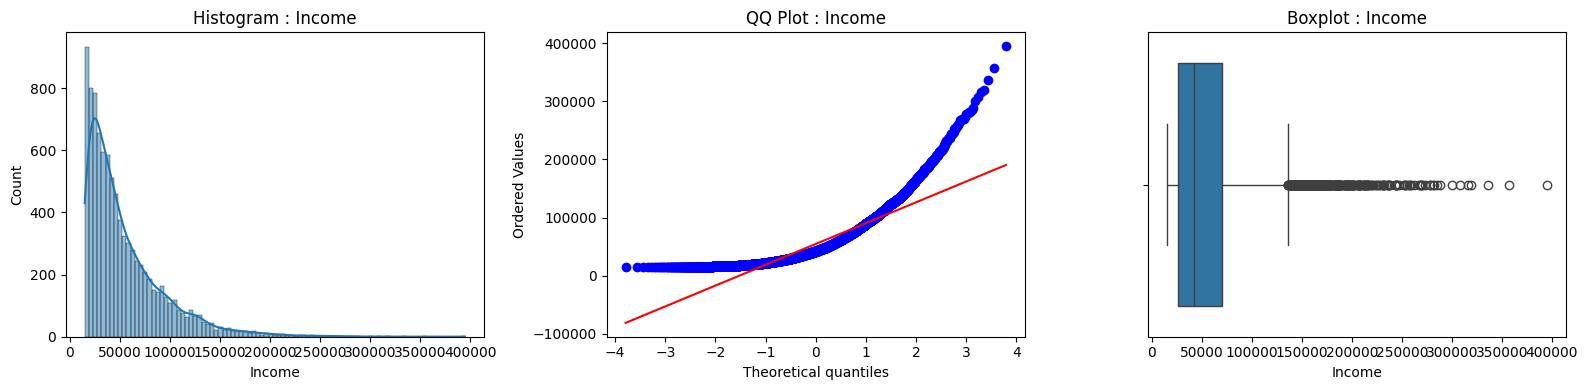

Minimum Value : 15002.00
Maximum Value : 394828.00
Mean          : 54542.31
Median        : 42020.00
Skewness      : 1.97
Outliers      : 411
Percentage    : 4.11%

Decision:
✔ Highly right-skewed
✔ Use log1p transformation
✔ Keep outliers if they are real


LoanAmount


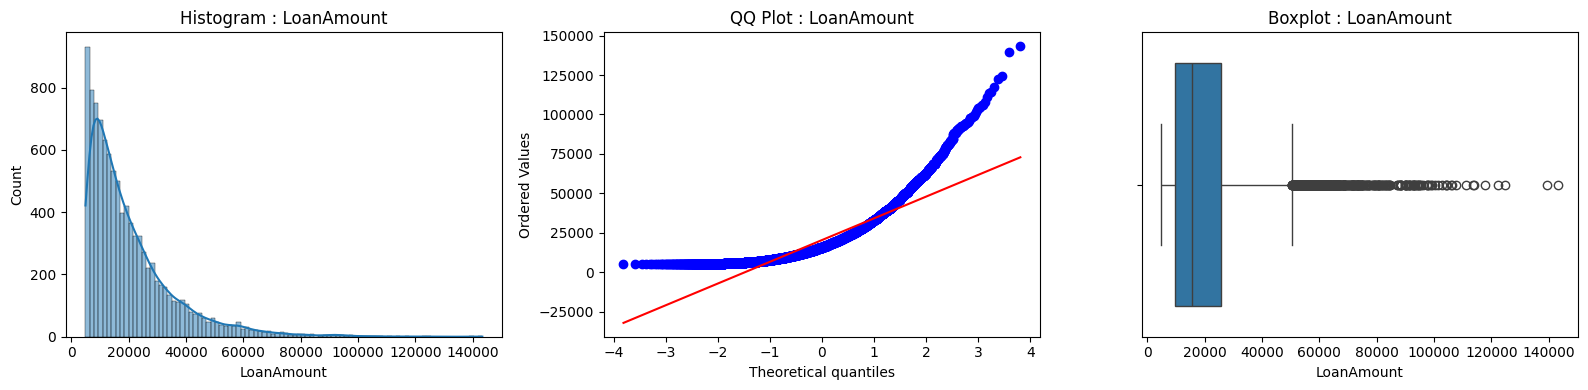

Minimum Value : 5000.00
Maximum Value : 143302.00
Mean          : 20351.79
Median        : 15731.50
Skewness      : 1.99
Outliers      : 522
Percentage    : 5.22%

Decision:
✔ Highly right-skewed
✔ Use log1p transformation
✔ Keep outliers if they are real


CreditScore


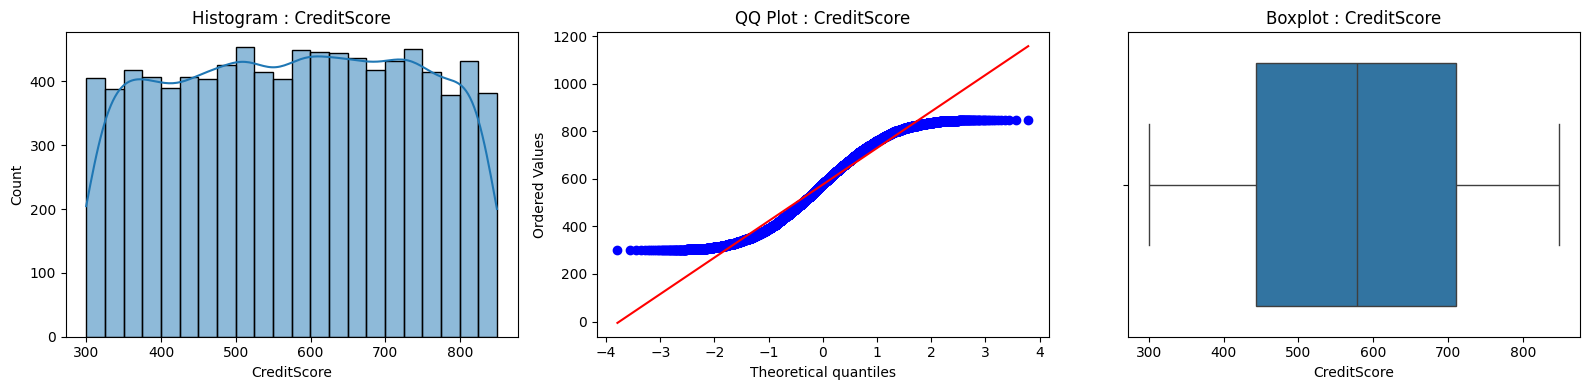

Minimum Value : 300.00
Maximum Value : 849.00
Mean          : 576.02
Median        : 579.00
Skewness      : -0.03
Outliers      : 0
Percentage    : 0.00%

Decision:
✔ Approximately normal
✔ Keep data
✔ StandardScaler


DebtToIncome


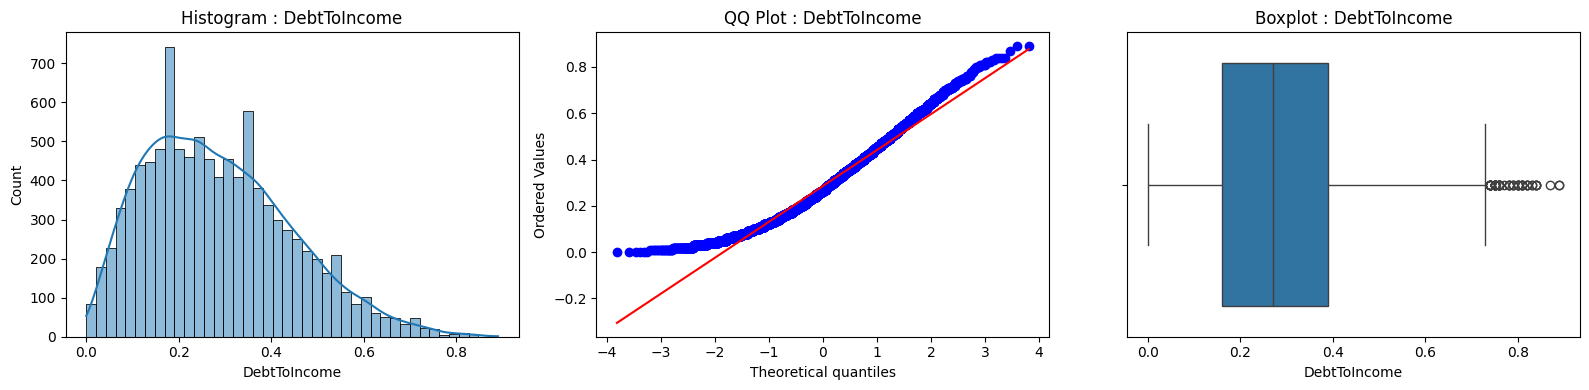

Minimum Value : 0.00
Maximum Value : 0.89
Mean          : 0.29
Median        : 0.27
Skewness      : 0.58
Outliers      : 62
Percentage    : 0.62%

Decision:
✔ Moderately skewed
✔ Consider PowerTransformer or Yeo-Johnson


EmploymentYears


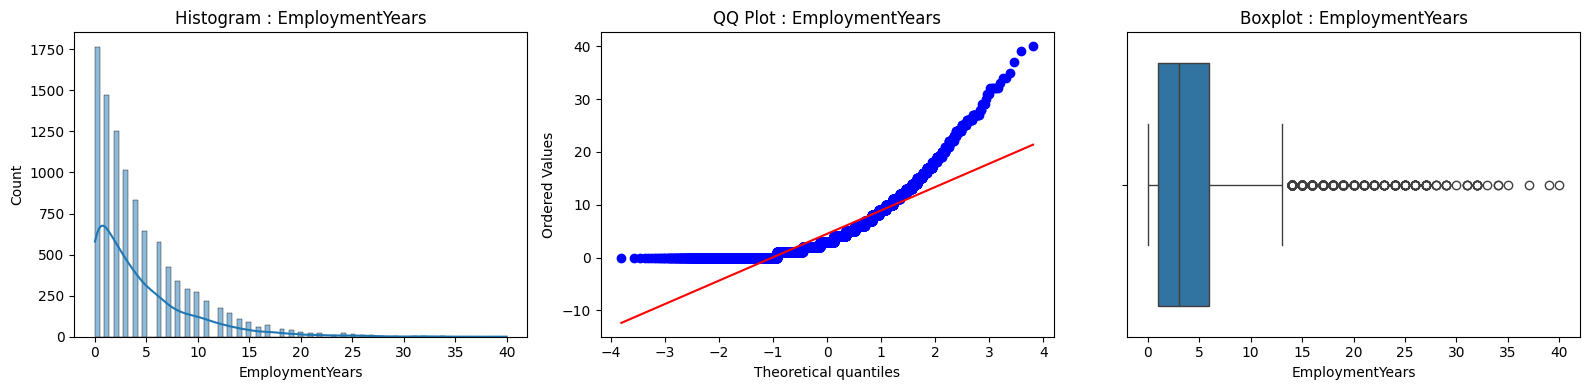

Minimum Value : 0.00
Maximum Value : 40.00
Mean          : 4.51
Median        : 3.00
Skewness      : 1.87
Outliers      : 586
Percentage    : 5.86%

Decision:
✔ Highly right-skewed
✔ Use log1p transformation
✔ Keep outliers if they are real


NumLatePayments


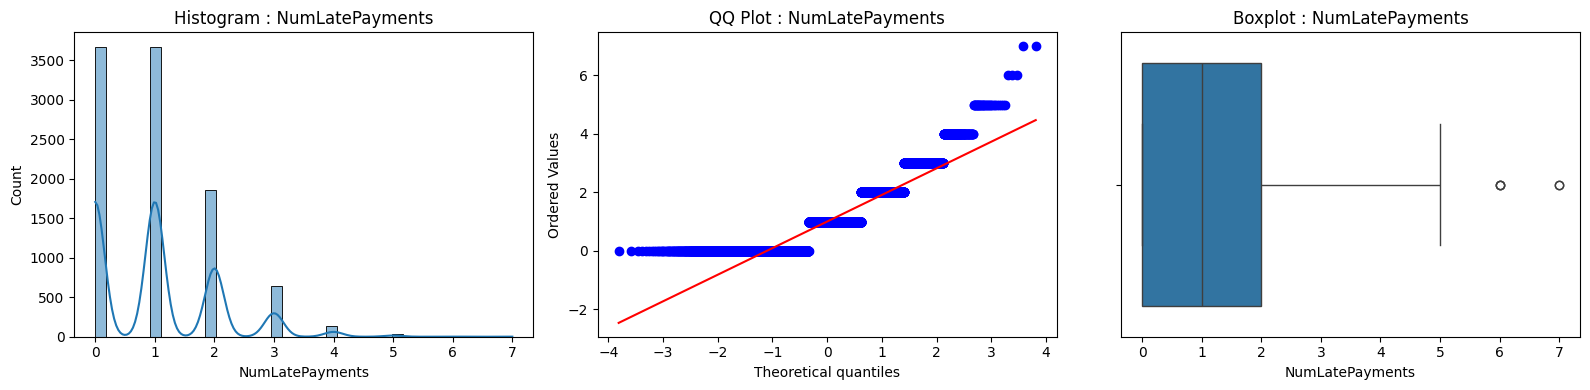

Minimum Value : 0.00
Maximum Value : 7.00
Mean          : 1.00
Median        : 1.00
Skewness      : 0.98
Outliers      : 5
Percentage    : 0.05%

Decision:
✔ Moderately skewed
✔ Consider PowerTransformer or Yeo-Johnson


NumCreditLines


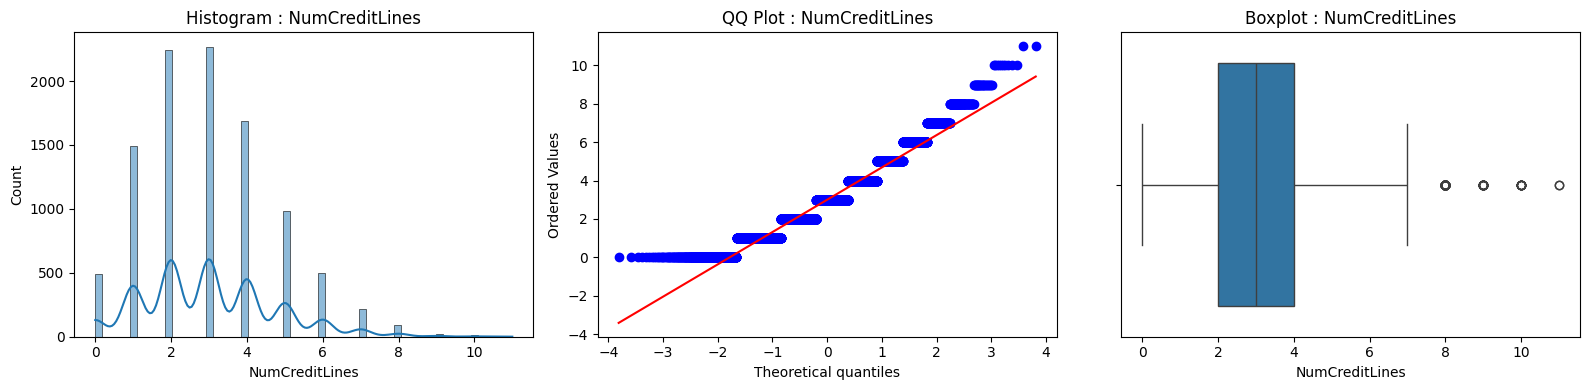

Minimum Value : 0.00
Maximum Value : 11.00
Mean          : 3.00
Median        : 3.00
Skewness      : 0.58
Outliers      : 124
Percentage    : 1.24%

Decision:
✔ Moderately skewed
✔ Consider PowerTransformer or Yeo-Johnson


Age


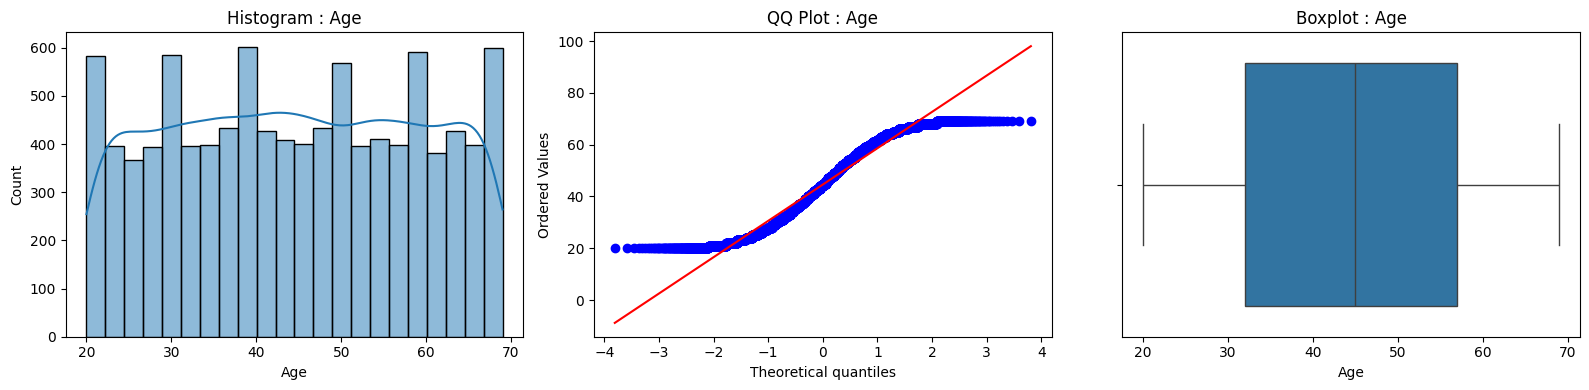

Minimum Value : 20.00
Maximum Value : 69.00
Mean          : 44.62
Median        : 45.00
Skewness      : -0.00
Outliers      : 0
Percentage    : 0.00%

Decision:
✔ Approximately normal
✔ Keep data
✔ StandardScaler


InterestRate


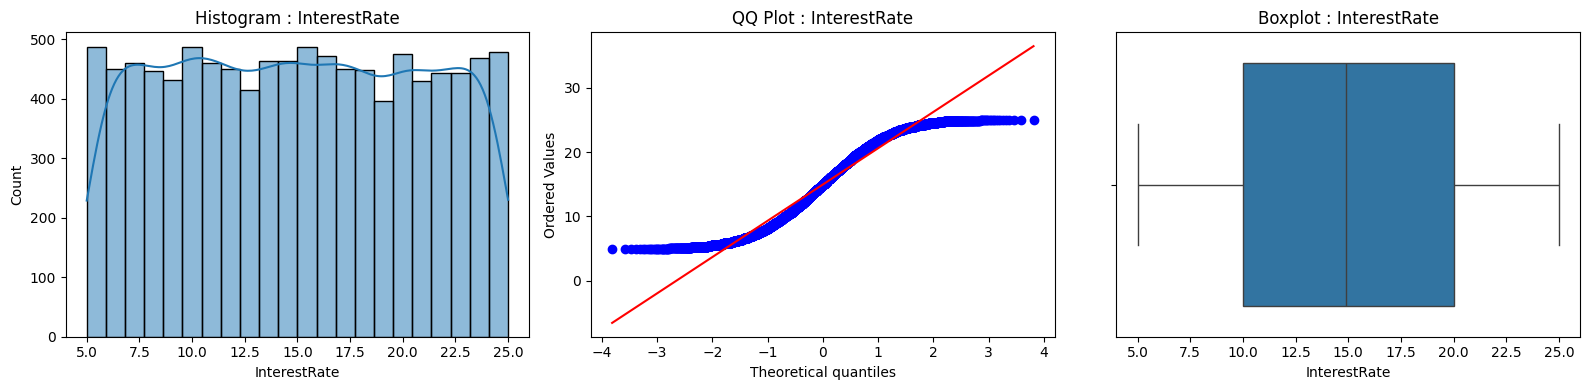

Minimum Value : 5.00
Maximum Value : 25.00
Mean          : 14.97
Median        : 14.90
Skewness      : 0.01
Outliers      : 0
Percentage    : 0.00%

Decision:
✔ Approximately normal
✔ Keep data
✔ StandardScaler




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================
# NUMERICAL COLUMNS
# ============================================

num_cols = [
    'Income',
    'LoanAmount',
    'CreditScore',
    'DebtToIncome',
    'EmploymentYears',
    'NumLatePayments',
    'NumCreditLines',
    'Age',
    'InterestRate'
]

# ============================================
# HISTOGRAM + QQ PLOT + BOXPLOT + OUTLIERS
# ============================================

for col in num_cols:

    print("="*80)
    print(f"{col}")
    print("="*80)

    # -----------------------------
    # Create 3 graphs
    # -----------------------------

    fig, ax = plt.subplots(1,3, figsize=(16,4))

    # Histogram
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Histogram : {col}")

    # QQ Plot
    stats.probplot(df[col].dropna(), dist="norm", plot=ax[1])
    ax[1].set_title(f"QQ Plot : {col}")

    # Box Plot
    sns.boxplot(x=df[col], ax=ax[2])
    ax[2].set_title(f"Boxplot : {col}")

    plt.tight_layout()
    plt.show()

    # =====================================
    # OUTLIER DETECTION (IQR)
    # =====================================

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"Minimum Value : {df[col].min():.2f}")
    print(f"Maximum Value : {df[col].max():.2f}")

    print(f"Mean          : {df[col].mean():.2f}")
    print(f"Median        : {df[col].median():.2f}")

    print(f"Skewness      : {df[col].skew():.2f}")

    print(f"Outliers      : {len(outliers)}")
    print(f"Percentage    : {(len(outliers)/len(df))*100:.2f}%")

    # =====================================
    # PROFESSIONAL DECISION
    # =====================================

    skew = df[col].skew()
    outlier_percent = (len(outliers)/len(df))*100

    print("\nDecision:")

    if abs(skew) < 0.5 and outlier_percent < 5:
        print("✔ Approximately normal")
        print("✔ Keep data")
        print("✔ StandardScaler")

    elif skew > 1:
        print("✔ Highly right-skewed")
        print("✔ Use log1p transformation")
        print("✔ Keep outliers if they are real")

    elif skew > 0.5:
        print("✔ Moderately skewed")
        print("✔ Consider PowerTransformer or Yeo-Johnson")

    elif outlier_percent > 10:
        print("✔ Many outliers")
        print("✔ Don't remove")
        print("✔ Use RobustScaler or tree-based models")

    else:
        print("✔ Check manually")
        print("✔ Remove only if data-entry error")

    print("\n")

In [ ]:

# ================================================================
# STEP 5 — CORRELATION WITH TARGET
# ================================================================
print("=" * 60)
print("STEP 5 — CORRELATION WITH TARGET")
print("=" * 60)

### grouby mean
df_corr=df.copy()
emp=df_corr.groupby(df['EmploymentType'])["Default"].mean()
emp1=df_corr.groupby(df['LoanPurpose'])["Default"].mean()
emp2=df_corr.groupby(df['PropertyStatus'])["Default"].mean()

print("GROUP BY EMPLOYMENT TYPE\n",emp)
print("GROUP BY LOAN PURPOSE\n",emp1)
print("GROUP BY PROPERTY STATUS\n",emp2)


## for num columns
print("__________ num_col______________")
df_corr=df.copy()
df_corr[num_cols].fillna(df_corr[num_cols].median(), inplace=True)
pearson=df_corr[num_cols].corrwith(df_corr["Default"],method="pearson")
#spearman=df_corr[num_cols].corrwith(df_corr["Default"],method="spearman")
pearson=pearson.sort_values(ascending=False)
print(pearson)

## for categorical columns #
print("_______________cateogrical column______________")
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

def cramers_v(column, target):

    table = pd.crosstab(df[column],df[target])

    chi2 = chi2_contingency(table)[0]

    n = table.sum().sum()

    rows, cols = table.shape

    v = np.sqrt(chi2 / (n * (min(rows, cols)-1)))

    return v

categorical_Col = [
    "EmploymentType",
    "LoanPurpose",
    "PropertyStatus"
]

for col in categorical_Col:

    value = cramers_v(col,"Default")

    print(f"{col:20} {value:.3f}")



STEP 5 — CORRELATION WITH TARGET
GROUP BY EMPLOYMENT TYPE
 EmploymentType
Part-Time        0.251546
Salaried         0.257419
Self-Employed    0.247120
Unemployed       0.566990
Name: Default, dtype: float64
GROUP BY LOAN PURPOSE
 LoanPurpose
Business     0.280839
Car          0.272959
Education    0.254572
Home         0.266799
Personal     0.275933
Name: Default, dtype: float64
GROUP BY PROPERTY STATUS
 PropertyStatus
Mortgage    0.261289
Own         0.277578
Rent        0.274392
Name: Default, dtype: float64
__________ num_col______________
NumLatePayments    0.146382
DebtToIncome       0.110708
Age                0.010499
Income            -0.001071
InterestRate      -0.002329
NumCreditLines    -0.007189
LoanAmount        -0.007344
EmploymentYears   -0.114290
CreditScore       -0.327874
dtype: float64
_______________cateogrical column______________
EmploymentType       0.156
LoanPurpose          0.020
PropertyStatus       0.016


/tmp/ipykernel_609/1507095979.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr[num_cols].fillna(df_corr[num_cols].median(), inplace=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
    OrdinalEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
import numpy as np

X = df.drop('Default', axis=1)
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)





### setting the columns # ==========================================================
# STEP 8 - COLUMN GROUPS
# ==========================================================

# KNN Imputer + log transform
income_col = ["Income"]

# Median Imputer
credit_col = ["CreditScore"]

# Highly right-skewed columns
log_cols = [
    "LoanAmount",
    "EmploymentYears"
]

# Normal numerical columns
numeric_cols = [
    "Age",
    "DebtToIncome",
    "InterestRate",
    "NumCreditLines",
    "NumLatePayments"
]

# Nominal categorical columns
categorical_cols = [
    "EmploymentType",
    "LoanPurpose"

]
### property column
ordinal_cat_cols = ['PropertyStatus']
property_order   = [['Own', 'Mortgage', 'Rent']]

# Already numeric
pass_cols = [
    "LoanTerm",
    "HasCoApplicant"
]
'''
# Ordinal categorical (HAS real order) → OrdinalEncoder
#   PropertyStatus: Own > Mortgage > Rent (decreasing stability)
ordinal_cat_cols = ['PropertyStatus']
property_order   = [['Own', 'Mortgage', 'Rent']]
property_pipe = Pipeline([
    ('ord', OrdinalEncoder(
        categories=property_order,            # Own=0, Mortgage=1, Rent=2
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
])

'''

# ==========================================================
# STEP 9 - CREATE PIPELINES
# ==========================================================

# Income
income_pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

# CreditScore
credit_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# LoanAmount, EmploymentYears
log_pipe = Pipeline([
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

# Standard Scaling
numeric_pipe = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical
categorical_pipe = Pipeline([
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

property_pipe = Pipeline([
    ('ord', OrdinalEncoder(
        categories=property_order,            # Own=0, Mortgage=1, Rent=2
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
])


# ==========================================================
# STEP 10 - COLUMN TRANSFORMER
# ==========================================================

preprocessor = ColumnTransformer([
    ("income", income_pipe, income_col),
    ("credit", credit_pipe, credit_col),
    ("log", log_pipe, log_cols),
    ("numeric", numeric_pipe, numeric_cols),
    ("categorical", categorical_pipe, categorical_cols),
    ('property', property_pipe, ordinal_cat_cols),
    ("pass", "passthrough", pass_cols)
])



# ==========================================================
# STEP 11 - PREPROCESS THE DATA
# ==========================================================

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(8000, 19)
(2000, 19)


In [ ]:
# creating the best model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             precision_recall_curve, roc_curve,
                             average_precision_score, confusion_matrix)





LR_model =  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
LR_model.fit(X_train_processed, y_train)

Y_pred_LR = LR_model.predict(X_test_processed)
Y_prob_LR = LR_model.predict_proba(X_test_processed)[:,1]


print(classification_report(y_test, Y_pred_LR))




from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)


print("Accuracy:",
      accuracy_score(y_test,Y_pred_LR))

print("ROC AUC:",
      roc_auc_score(y_test,Y_pred_LR))

              precision    recall  f1-score   support

           0       0.86      0.68      0.76      1462
           1       0.44      0.70      0.54       538

    accuracy                           0.68      2000
   macro avg       0.65      0.69      0.65      2000
weighted avg       0.75      0.68      0.70      2000

Accuracy: 0.683
ROC AUC: 0.6897817828609787


In [ ]:
'''
First look at the report
              precision    recall  f1-score   support

           0       0.86      0.68      0.76      1462
           1       0.44      0.70      0.54       538

Accuracy = 0.683

First understand what your classes mean.

0 = Good customer (No Default)

1 = Bad customer (Default)

Your dataset contains

1462 good customers

538 bad customers

Total

1462 + 538 = 2000

So

73%
good customers

27%
bad customers
Step 1 Accuracy
Accuracy = 0.683

means

Out of

2000

customers

the model predicted correctly

68.3%

That means

2000 × 0.683

≈1366 predictions correct

Wrong

634 predictions

Is Accuracy enough?

No.

Because imagine

100 people

95 are good

5 are bad

Model predicts

Everyone is good.

Accuracy becomes

95%

But it never catches a bad customer.

That model is useless.

That's why we use

Precision

Recall

F1

ROC AUC
Look at Class 0
0 = Good customer
Precision

0.86

Meaning

Whenever the model says

"This customer is GOOD"

It is correct

86%

of the time.

Example

Model predicts

100 good customers

Actually

86

really good

14

actually bad

Now Recall

Recall

0.68

Meaning

There were actually

1462

good customers

The model found

68%

of them.

Example

Actually

1462

good customers exist.

Model correctly found

994

and missed

468

good customers.

F1
0.76

F1 balances

Precision

and

Recall

Higher is better.

Now look at Class 1
1 = Default

This is usually the important class.

Precision

0.44

Very important.

This means

Whenever the model says

"This customer will default."

Only

44%

actually default.

Example

Suppose

Model predicts

100 defaults

Reality

44

really default

56

actually good customers

That means

56 good customers

would be wrongly rejected.

Banks lose customers.

Recall

0.70

This is much better.

It means

There are actually

538

bad customers

The model catches

70%

of them.

Example

538

bad customers exist.

Model catches

377

Misses

161

bad customers.

Missing a bad customer means

You approve

someone

who will

not repay.

That costs money.

F1
0.54

Because

Precision is low

Recall is good

F1 becomes moderate
'''